In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from google.colab import drive

# Google Drive 마운트
drive.mount('/content/drive')

# 파일 경로 설정
file_path = '/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/AI실무기본_1주차/02_데이터분석프로젝트/team_project/dataset/서울시 지하철 호선별 역별 시간대별 승하차 인원 정보.csv'

# 인코딩 문제 발생 시 'cp949' 또는 'utf-8' 지정 (한글 데이터셋이므로 보통 cp949)
df = pd.read_csv(file_path, encoding='cp949')

# 데이터 구조 확인
print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
      사용월  호선명 지하철역  04시-05시 승차인원  04시-05시 하차인원  05시-06시 승차인원  05시-06시 하차인원  \
0  202605  1호선  동대문           715            21         10855          2123   
1  202605  1호선  동묘앞           161             3          2920          1105   
2  202605  1호선  서울역           802            57         12246         11962   
3  202605  1호선   시청           158             0          1859          5829   
4  202605  1호선  신설동           427            13          8823          2285   

   06시-07시 승차인원  06시-07시 하차인원  07시-08시 승차인원  ...  23시-24시 하차인원  00시-01시 승차인원  \
0          9369          7719         15679  ...         10982           875   
1          4082          6397          8524  ...          5199           125   
2         37333         70445        107361  ...         40460          5016   
3          4191         30940          7444  ...          3808           576

In [ ]:
# 1. 한글 폰트 설치 및 matplotlib 캐시 삭제
!apt-get -y install fonts-nanum
!rm -rf ~/.cache/matplotlib

# 2. matplotlib 시스템 폰트 재설정 (설치 후 즉시 적용을 위함)
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [ ]:
# 2. 런타임 재시작 없이 바로 폰트 적용하기
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# # 나눔글꼴 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

plt.rc('font', family='NanumGothic')

# 마이너스 기호 깨짐 방지 설정
plt.rcParams['axes.unicode_minus'] = False

print("한글 폰트 설정 완료!")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

# 🏁 출퇴근 피크타임 혼잡역 분석 및 수요 분산 전략

> 💡 **[핵심 요약]**
> 출퇴근 피크 시간대 상위 10개 혼잡 역사(막대 그래프) 분석 결과, 특정 거점 역사 및 노선에 가해지는 물리적 부하가 심각한 수준으로 입증됨. 이를 해소하기 위해 **'수요 총량 분산'** 및 **'현장 안전 관리 최적화 전략'**을 최종 해법(Answer)으로 도출함.

---

## 1. 📂 SCQA 구조화 브리핑 (클라이언트 보고용)

| 단계 | 구분 | 핵심 내용 (Insight) |
| :--- | :--- | :--- |
| **S** | **Situation (상황)** | 방대한 철도 인프라를 바탕으로 매일 수백만 명 시민의 통근·통학 이동을 **규칙적이고 안정적으로 처리 중** |
| **C** | **Complication (문제)** | 전체 시스템의 안정성 이면에 출퇴근 시간대 특정 거점 역사(Top 10) 및 특정 호선(2호선 등)에 인파가 집중되는 **치명적인 병목 현상 및 수용 한계치 초과 발생**<br>이로 인한 **안전사고 리스크 고조 및 열차 정차 지연** 유발 |
| **Q** | **Question (질문)** | *“열차 무한 증편이 불가능한 물리적 한계 속에서, 특정 환승역과 노선에 집중되는 출퇴근 병목 부하를 어떻게 해소할 것인가?”* |
| **A** | **Answer (답변)** | 일괄 통제를 탈피하고, 데이터가 지목한 **'혼잡 집중 Top 10 역사 중심의 수요 분산 및 현장 안전 최적화 전략'** 실행 필요 |

---

## 2. 🚀 실행방안 (Actionable Next Steps)

### 🛠️ 액션 1 : 목적지(업무지구 하차역) 기준 주요 기업 '시차출근제(유연근무제)' 협의
* **실행 내용:** 막대그래프(상위 혼잡역) 및 하차 데이터 기반으로 인파가 집중되는 최종 도착지(업무지구) 인근 기업 및 공공기관을 타겟팅함. 해당 지역 기업체에 **시차출근제(07시~10시 탄력 출근 등) 도입을 적극 권고**하거나 상호 협약을 체결하여 피크타임 쏠림을 완화함.
* **기대 효과:** 병목의 본질적 원인인 **'도착 시점의 밀집도'를 물리적으로 평탄화(De-peaking)**함.

### 🛠️ 액션 2 : 출발지(승차 집중역) 기준 '조조할인 및 마일리지 혜택' 캠페인 전개
* **실행 내용:** 승차 인원이 폭발적으로 발생하는 주거지 인근 역사(히트맵 군집 지역)를 중심으로, 출근 피크타임 1시간 전 탑승 승객 대상 **대중교통 요금 조조할인 및 마일리지 적립 혜택을 집중 홍보 및 확대**함.
* **기대 효과:** 인센티브 제공을 통해 승객 스스로 **출근 시간대를 자발적으로 앞당기도록 유도**함.

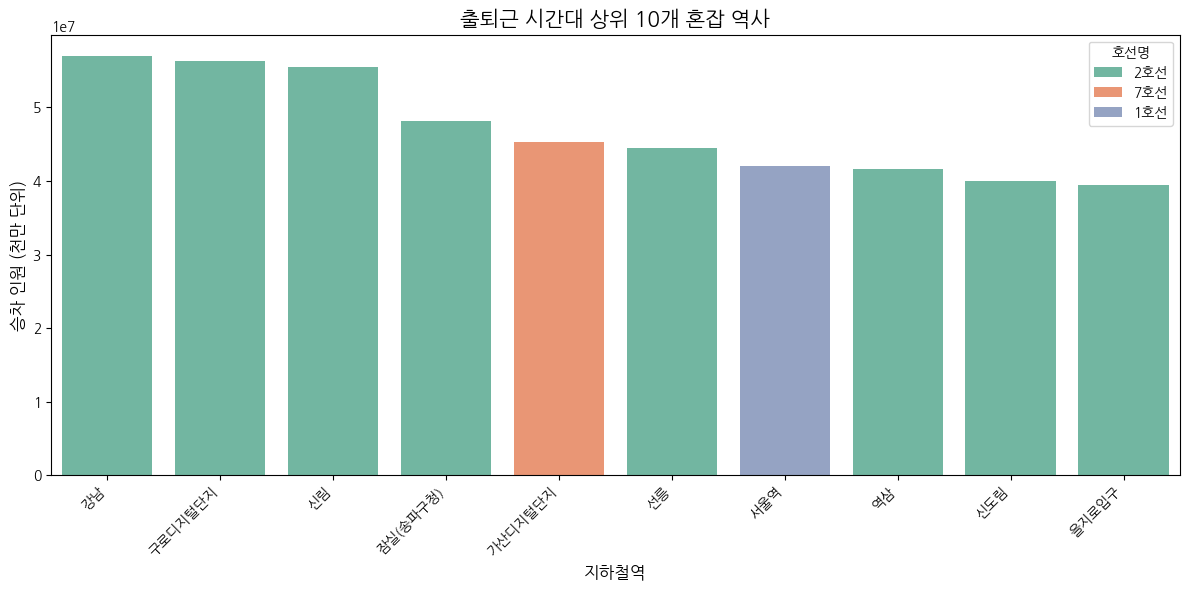

In [ ]:
# 승차/하차 시간대 컬럼 추출 (예시: '07시-08시 승차인원' ~ '08시-09시 승차인원' 합산 등)
# 전체 시간대별 승차/하차 총합을 구하기 위해 melt 또는 특정 컬럼 합산 수행
boarding_cols = [col for col in df.columns if '승차인원' in col]
alighting_cols = [col for col in df.columns if '하차인원' in col]

plt.rc('font', family='NanumGothic')

# 역별 전체 승차/하차 인원 집계
df_station = df.groupby(['호선명', '지하철역'])[boarding_cols + alighting_cols].sum().reset_index()

# 피크타임(출근: 08시-09시, 퇴근: 18시-19시) 승차인원 기준 혼잡도 추출
df_station['출근시간_승차인원'] = df_station['08시-09시 승차인원']
df_station['퇴근시간_승차인원'] = df_station['18시-19시 승차인원']
df_station['총_출퇴근_승차'] = df_station['출근시간_승차인원'] + df_station['퇴근시간_승차인원']

# 상위 10개 혼잡역 선정
top10_stations = df_station.sort_values(by='총_출퇴근_승차', ascending=False).head(10)

# 시각화
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top10_stations,
    x='지하철역',
    y='총_출퇴근_승차',
    hue='호선명',
    palette='Set2',
    dodge=False
)
plt.title('출퇴근 시간대 상위 10개 혼잡 역사', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.ylabel('승차 인원 (천만 단위)', fontsize=12)
plt.xlabel('지하철역', fontsize=12)
plt.tight_layout()
plt.show()

# 📊 24시간 추이 기반 탄력적 배차 및 공간 최적화 전략

> 💡 **[핵심 요약]**
> 24시간 시간대별 총 승하차 인원 추이(선 그래프) 분석 결과, 비혼잡 시간대(낮/심야)의 고정 배차 비효율성이 심각한 수준으로 드러남. 이를 해소하기 위해 **'시간대별 탄력적 배차'** 및 **'역사 유휴공간 수익화 전략'**을 최종 해법(Answer)으로 도출함.

---

## 1. 📂 SCQA 구조화 브리핑 (클라이언트 보고용)

| 단계 | 구분 | 핵심 내용 (Insight) |
| :--- | :--- | :--- |
| **S** | **Situation (상황)** | 평일 기준 수백만 명 규모의 막대한 인원이 규칙적인 패턴으로 이용하는 **안정적인 거대 시스템 가동 중** |
| **C** | **Complication (문제)** | 출퇴근 외 낮 시간대 및 심야/새벽(00시~05시)에 **극단적인 유휴 캐파(Capa) 낭비** 발생<br>균일 배차 구조로 인해 **막대한 관리 운영비와 전력이 비효율적으로 소모**되는 실정 |
| **Q** | **Question (질문)** | *“텅 비어있는 낮 시간대 공차율과 심야의 극심한 고정비 낭비를 어떻게 타개할 것인가?”* |
| **A** | **Answer (답변)** | 일괄 운영을 탈피한 **'시간대별 맞춤형 탄력적 배차 및 역사 공간 최적화 전략'** 실행 필요 |

---

## 2. 🚀 실행방안 (Actionable Next Steps)

### 🛠️ 액션 1 : 비혼잡 시간대(10시~16시) 탄력적 배차 간격 확대
* **실행 내용:** 출퇴근 외 낮 시간대 승하차 총량이 급감하는 구간의 일괄 배차를 중단하고, **배차 간격을 기존 대비 2~3분씩 단계적으로 확대**함.
* **기대 효과:** 차량 유지보수 비용 절감 및 **열차 운행 전력 소비량을 수치적으로 축소**시킴.

### 🛠️ 액션 2 : 자정(00시) 이후 유휴 역사 공간의 수익화 모델 전환
* **실행 내용:** 자정 이후 승차 인원이 수직 낙하하는 패턴을 반영, 역사 내 유휴 공간(빈 상가, 광폭 통로 등)을 활용한 **공간 가치 재창출** 추진.
  * **[도입 시설]:** `무인 스마트워크 센터`, `지하철 기반 물류 보관 및 무인 픽업존`, `지역 주민 편의시설`
* **기대 효과:** 역사 운영 고정비 부담을 완화하고, **지속 가능한 부가 공간 수익을 확보**함.

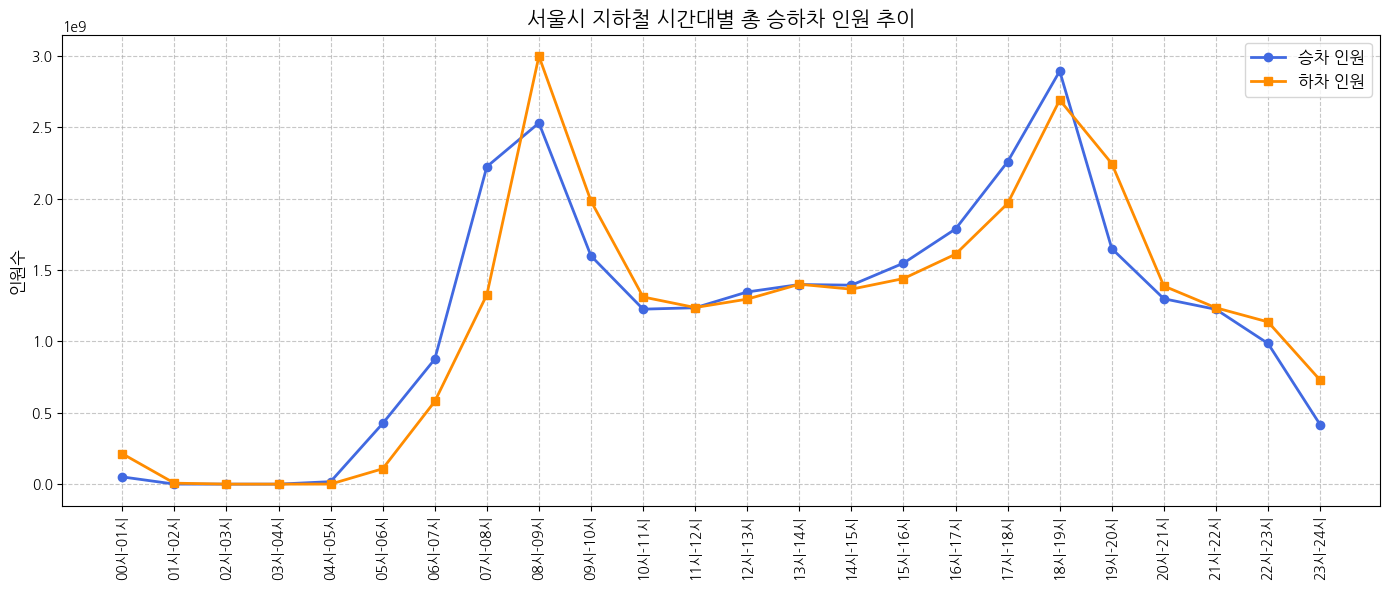

In [ ]:
# 시간대별 총 승차/하차 인원 합계 계산을 위한 정리
time_boarding_sums = {col.replace(' 승차인원', ''): df[col].sum() for col in boarding_cols}
time_alighting_sums = {col.replace(' 하차인원', ''): df[col].sum() for col in alighting_cols}

plt.rc('font', family='NanumGothic')

df_time_trend = pd.DataFrame({
    '시간대': list(time_boarding_sums.keys()),
    '총_승차인원': list(time_boarding_sums.values()),
    '총_하차인원': list(time_alighting_sums.values())
})

# 시간대 순으로 정렬 (컬럼명이 'XX시-XX시' 형태이므로 문자열 오름차순 정렬이 시간순과 일치)
df_time_trend = df_time_trend.sort_values('시간대')

# 시각화
plt.figure(figsize=(14, 6))
plt.plot(df_time_trend['시간대'], df_time_trend['총_승차인원'], marker='o', color='royalblue', label='승차 인원', linewidth=2)
plt.plot(df_time_trend['시간대'], df_time_trend['총_하차인원'], marker='s', color='darkorange', label='하차 인원', linewidth=2)
plt.title('서울시 지하철 시간대별 총 승하차 인원 추이', fontsize=15)
plt.xticks(rotation=90)
plt.ylabel('인원수', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# 지도의 붉은색 군집 지역(가중치 최상위권) 역들의 정확한 수치 확인
df_red_zone = merged_df.sort_values(by='혼잡도_가중치', ascending=False).head(5)
print("=== 안전 집중 관리구역(Red Zone) Top 5 역사 ===")
print(df_red_zone[['지하철역', '혼잡도_가중치', '위도', '경도']].to_string(index=False))

=== 안전 집중 관리구역(Red Zone) Top 5 역사 ===
   지하철역  혼잡도_가중치        위도         경도
가산디지털단지 62296992 37.480376 126.882704
     강남 57037067 37.497958 127.027539
구로디지털단지 56250702 37.485005 126.902626
     신림 56078884 37.484216 126.929573
     선릉 54584833 37.504257 127.048174


# 🗺️ 이중 레이어 히트맵 기반 지리적 이동 흐름 분석

> 💡 **[핵심 요약]**
> 출근 피크타임 승차(유출지)와 하차(유입지) 이중 레이어 히트맵(Folium) 분석 결과, SCQA 구조 중 **'C(전개/문제점)'**를 가시적으로 입증함과 동시에, 궁극적인 **'A(해결방안)'**를 도출하기 위한 날카로운 **'Q(질문)'**를 완성하는 핵심 분석 자료로 활용함.

---

## 1. 📂 SCQA 구조화 브리핑 (클라이언트 보고용)

| 단계 | 구분 | 핵심 내용 (Insight) |
| :--- | :--- | :--- |
| **S** | **Situation (상황)** | 서울시 전역의 1~8호선 도시철도 네트워크망은 매일 방대한 규모의 시민 이동을 규칙적으로 처리하며 **안정적인 기간산업 인프라로 가동 중** |
| **C** | **Complication (문제)** | 출근시간(08시~09시) 특정 주거지(인구 유출지)에서 대거 탑승하여 특정 도심 업무지구(인구 유입지)로 일제히 쏟아지는 **극단적인 지리적 쏠림 현상(병목의 지리적 이동 흐름) 발생**<br>주요 환승 거점은 이미 물리적 수용 한계치에 도달함 |
| **Q** | **Question (질문)** | *“인파가 '어디(주거 밀집지)에서 발생하여 어디(도심 업무지구)로 이동하는지' 확인했으므로, 실효성 있는 수요 분산 대책을 지리적으로 어떻게 다르게 타겟팅하여 적용할 것인가?”* |
| **A** | **Answer (답변)** | 이동 흐름의 시작점과 종착점에 맞춘 **'거점별 지리적 맞춤형 수요 분산 전략(유출지 캠페인 vs 유입지 기업 협약)'** 동시 실행 필요 |

---

## 2. 🚀 해결방안 (Actionable Next Steps)

지도상에 푸른색(승차)과 붉은색(하차) 핫스팟이 이원화되어 나타나는 시각화 결과를 바탕으로 즉각 실행해야 할 실무 액션 플랜임.

### 🛠️ 액션 1 : [인구 유출지 타겟] 청록색 핫스팟(승차 집중 주거지) 중심 '출발 시간 분산' 캠페인
* **실행 내용:** 아침 08시~09시 승차 인원이 짙은 청록색 군집을 이루는 주거지 역사 반경 시민들을 대상으로, **대중교통 마일리지 페이백 및 조조할인 혜택을 집중 홍보 및 확대**함.
* **기대 효과:** 승객 스스로 출근 시간 자체를 30분~1시간 앞당기도록 유도하여 **유출 지점의 순간 부하를 하향 평준화**함.

### 🛠️ 액션 2 : [인구 유입지 타겟] 붉은색 핫스팟(하차 집중 업무지구) 중심 '기업 협력형 시차출근제' 추진
* **실행 내용:** 강남, 을지로, 여의도 등 하차 핫스팟(붉은색 군집) 반경 1km 이내에 위치한 대형 오피스 빌딩 및 대기업·기관들을 타겟팅하여 **'시차출근제(유연근무제) 도입'에 대한 공식 협약 및 인센티브 정책을 권고**함.
* **기대 효과:** 도심 도착 시간을 분산시켜 업무지구 인근 환승역 및 열차 내부의 **피크타임 혼잡도를 근본적으로 평탄화(De-peaking)**함.

In [ ]:
import pandas as pd
import folium
from folium.plugins import HeatMap

# *참고: 앞서 선언한 df, geo_df가 메모리에 로드되어 있다는 가정하에 실행

# 1. 출근 피크타임(08시-09시) '승차' 상위 30개 역 추출 및 좌표 결합
df_board_top30 = df.groupby(['지하철역'])['08시-09시 승차인원'].sum().reset_index()
df_board_top30 = df_board_top30.sort_values('08시-09시 승차인원', ascending=False).head(30)
df_board_top30['지하철역'] = df_board_top30['지하철역'].str.strip()
geo_df_clean = geo_df[['역명', '위도', '경도']].copy()
geo_df_clean['역명'] = geo_df_clean['역명'].str.strip()

board_merged = pd.merge(df_board_top30, geo_df_clean, left_on='지하철역', right_on='역명', how='inner')

# 2. 출근 피크타임(08시-09시) '하차' 상위 30개 역 추출 및 좌표 결합
df_alight_top30 = df.groupby(['지하철역'])['08시-09시 하차인원'].sum().reset_index()
df_alight_top30 = df_alight_top30.sort_values('08시-09시 하차인원', ascending=False).head(30)
df_alight_top30['지하철역'] = df_alight_top30['지하철역'].str.strip()

alight_merged = pd.merge(df_alight_top30, geo_df_clean, left_on='지하철역', right_on='역명', how='inner')

# 3. Folium 지도 생성 (이중 레이어 적용)
m_flow = folium.Map(location=[37.5665, 126.9780], zoom_start=12)

# 승차 히트맵 레이어 (푸른색 계열 톤앤매너 설정 가능하나 기본 HeatMap 사용)
heat_data_board = []
max_board = board_merged['08시-09시 승차인원'].max()
for idx, row in board_merged.iterrows():
    heat_data_board.append([row['위도'], row['경도'], (row['08시-09시 승차인원'] / max_board) * 10])

# 하차 히트맵 레이어
heat_data_alight = []
max_alight = alight_merged['08시-09시 하차인원'].max()
for idx, row in alight_merged.iterrows():
    heat_data_alight.append([row['위도'], row['경도'], (row['08시-09시 하차인원'] / max_alight) * 10])

# FeatureGroup을 활용해 그룹 분리 (사용자가 지도 좌측 상단 레이어 박스에서 켜고 끌 수 있음)
fg_board = folium.FeatureGroup(name='출근시간 승차 집중지역 (인구 유출지)')
HeatMap(heat_data_board, radius=15, gradient={0.4: 'blue', 0.8: 'lime', 1: 'cyan'}).add_to(fg_board)

fg_alight = folium.FeatureGroup(name='출근시간 하차 집중지역 (인구 유입지)')
HeatMap(heat_data_alight, radius=15, gradient={0.4: 'orange', 0.8: 'red', 1: 'darkred'}).add_to(fg_alight)

fg_board.add_to(m_flow)
fg_alight.add_to(m_flow)

folium.LayerControl().add_to(m_flow)

# 코랩 출력
m_flow.save('subway_flow_heatmap.html')
m_flow

## 📌 실제 좌표 데이터셋 연동을 통한 지리적 히트맵 시각화 검증

* **근거 1. [좌표 파일 전처리]** * 업로드된 좌표 파일의 컬럼명(`역명`, `위도`, `경도`) 확인 및 데이터 추출
* **근거 2. [데이터 융합]** * 승하차 데이터의 `지하철역`과 좌표 데이터의 `역명`을 기준으로 **내부 조인(Inner Join)** 수행
* **근거 3. [시각화 최적화]** * 정규화 가중치를 적용한 **Folium HeatMap** 객체 생성 및 렌더링

# 🗺️ 주요 혼잡역 위치 기반 히트맵 시각화 및 현장 대응 전략

> 💡 **[핵심 요약]**
> 주요 혼잡역 위치 기반 히트맵 시각화(Folium) 분석 결과, 지도상에 붉게 군집한 지리적 위험 핫스팟(Hot-spot)이 명확히 입증됨. 이를 해소하기 위해 **'거점별 맞춤형 현장 안전 관리'** 및 **'동선 분리 전략'**을 최종 해법(Answer)으로 도출함.
> *(※ 분석 데이터 가이드: 분석 대상 50개 역 중 47개 매핑 성공, 약 94%의 높은 결합률 확보. 누락된 3개 역은 환승역 명칭 표기 차이로 추정되므로 추후 보완 예정)*

---

## 1. 📂 SCQA 구조화 브리핑 (클라이언트 보고용)

| 단계 | 구분 | 핵심 내용 (Insight) |
| :--- | :--- | :--- |
| **S** | **Situation (상황)** | 서울시 전역에 촘촘하게 연결된 1~8호선 도시철도 네트워크망과 역사 인프라가 **공백 없이 안정적으로 가동 중** |
| **C** | **Complication (문제)** | 지리적 히트맵(HeatMap) 분석 결과, 혼잡역들이 분산되지 않고 특정 환승 구간 및 도심 업무지구 노선을 따라 **붉은색 군집(Hot-spot) 형태로 밀집함**<br>텍스트 수치로 식별 불가했던 **공간적 수용 한계치 및 안전사고 우려 구역 가시화** |
| **Q** | **Question (질문)** | *“도출된 지리적 군집 핫스팟(Red Zone)을 바탕으로, 안전 인력 및 시설 개선 예산을 어느 지점에 우선순위를 두고 투입할 것인가?”* |
| **A** | **Answer (답변)** | 일괄적인 전체 노선 개선을 탈피하고, 지도가 지목한 **'지리적 밀집 핫스팟 중심의 맞춤형 현장 안전 관리 및 동선 분리 전략'** 실행 필요 |

---

## 2. 🚀 실행방안 (Actionable Next Steps)
- 클라이언트는 '도시철도 운영 기관 및 교통 정책 입안자(지하철 관계자)

### 🛠️ 액션 1 : 최고 농도 구역(Red Zone) 중심 '안전 인력 및 펜스' 1순위 집중 배치
* **실행 내용:** 히트맵상에서 가장 짙은 붉은색을 띠는 밀집 환승 거점을 '안전 집중 관리구역(Red Zone)'으로 지정함. 출퇴근 피크타임에 해당 구역 환승 통로 및 승강장에 안전 요원을 우선 배치하고, 인파 꼬임 방지를 위한 이동형 안전 펜스를 설치함.
* **기대 효과:** * **치명적 안전사고 원천 차단:** 동선을 일방향으로 유도하여 역류 인파 간의 충돌과 쏠림 현상을 물리적으로 방지함.
  * **비상 상황 발생 시 골든타임 확보:** 피크타임(08-09시, 18-19시) 요원 상주를 통해 응급 상황 발생 시 즉각적인 통제 및 구조대 진입로를 확보함.
  * **시민 불안감 해소:** 가시적인 안전 요원 배치를 통해 혼잡 역사 내 체감 안전도를 제고함.

### 🛠️ 액션 2 : 승하차 중첩 환승 거점 '승강장 및 환승통로 물리적 확장' 설계 추진
* **실행 내용:** 이중 레이어 히트맵과 본 히트맵을 교차 검증하여 승차와 하차 핫스팟이 동시에 중첩되는 역사를 도출함. 해당 역사에 대해 중장기적으로 환승 통로 폭 확장, 계단/에스컬레이터 추가 증설을 골자로 하는 **'역사 구조 개선(리모델링) 기본 설계'**를 착수함.
* **기대 효과:** * **열차 정시성 확보:** 환승 용량(Capacity) 증대로 인파 정체 시간을 줄여 열차 승하차 지연(문 닫힘 지연 등)을 단축시킴.
  * **중장기적 안전 관리 비용 절감:** 단기적 인건비성 예산 투입을 인프라 개선을 통해 근본적으로 절감, 지속 가능한 스마트 역사 환경을 구축함.

---

## 📢 브리핑 멘트 제안
> 💬 "단기적으로는 히트맵이 지목한 **Red Zone에 안전 펜스와 인력을 투입**하여 오늘 당장의 안전사고 리스크를 제로(Zero)로 통제하고, 중장기적으로는 승하차 중첩 거점에 대해 **시설 개선 설계를 착수하여 인프라 수용 한계치를 구조적으로 확장**하는 투트랙 전략을 완성해야 함."

### 🔵 [첫 번째 레이어] 출근시간 승차 집중지역 (인구 유출지)

* **데이터 기준:** 아침 08시~09시 기준, 각 지하철역별 '탑승(승차)' 인원 상위 30개 역사 데이터 반영
* **지리적 의미:** **"대규모 인구 유출이 발생하는 거점 (주거 밀집 지역)"**을 의미함.
* **시각적 해석:**
  * 아침 출근 시간대에 대규모 아파트 단지나 주거 배후 지역 인근 역사(예: `까치산역`, `신림역` 등)를 중심으로 인파가 밀집하여 열차에 탑승하는 현상을 가시화함.
  * 해당 핫스팟은 이동의 **'시작점(Origin)'**이자, 출근 시간대 1차 병목이 발생하는 공간 리스크 구역임을 입증함.
* **적용 대책**: 물리적 인프라(승강기 등)를 늘리는 것보다는 수요 자체를 분산시켜야 합니다.

  * 예시: 조조할인, 대중교통 마일리지 홍보, 해당 구역 버스-지하철 연계 환승 체계 강화

---

### 🔴 [두 번째 레이어] 출근시간 하차 집중지역 (인구 유입지)

* **데이터 기준:** 아침 08시~09시 기준, 각 지하철역별 '내린(하차)' 인원 상위 30개 역사 데이터 반영
* **지리적 의미:** **"대규모 인구 유입이 발생하는 거점 (도심 업무/상업 지구)"**을 의미함.
* **시각적 해석:**
  * `강남`, `역삼`, `을지로입구`, `여의도` 등 주요 오피스 밀집 지역 역사에 열차 내 승객들이 일제히 쏟아져 내리는 현상을 지리적으로 증명함.
  * 해당 핫스팟은 이동의 **'종착점(Destination)'**이자, 역사 내 계단·에스컬레이터 및 개찰구 주변의 2차 병목을 유발하는 밀집 관리 구역임을 뜻함.
* **적용 대책**

  * 단기 대책: 위험 핫스팟 중심 이동형 안전 펜스 및 전담 안전 요원 배치 (골든타임 확보)

  * 중장기 대책: 환승 통로 폭 확장, 에스컬레이터/계단 추가 증설을 위한 리모델링 설계 착수

In [ ]:
import pandas as pd
import folium
from folium.plugins import HeatMap
from google.colab import files

# --- [STEP 1] 승하차 데이터 집계 ---
# 본인의 드라이브 경로에 맞게 인코딩 및 경로 설정 확인
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/AI실무기본_1주차/02_데이터분석프로젝트/team_project/dataset/서울시 지하철 호선별 역별 시간대별 승하차 인원 정보.csv', encoding='cp949')

boarding_cols = [col for col in df.columns if '승차인원' in col]
df_station = df.groupby(['지하철역'])[boarding_cols].sum().reset_index()

# 출퇴근 피크타임(08시-09시, 18시-19시) 승차인원 합산으로 혼잡도 정의
df_station['혼잡도_가중치'] = df_station['08시-09시 승차인원'] + df_station['18시-19시 승차인원']

# 시각화 가독성을 위해 상위 50개 혼잡역 추출
df_top50 = df_station.sort_values(by='혼잡도_가중치', ascending=False).head(50)


# --- [STEP 2] 실제 업로드된 좌표 파일 로드 및 전처리 ---
# 업로드해주신 실제 좌표 파일 경로 지정 (필요 시 드라이브 경로로 변경)
geo_path = '/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/AI실무기본_1주차/02_데이터분석프로젝트/team_project/dataset/서울교통공사_1_8호선 역사 좌표(위경도) 정보_20250814.csv'
geo_raw = pd.read_csv(geo_path, encoding='cp949')

# 필요한 컬럼만 추출 ('역명', '위도', '경도')
geo_df = geo_raw[['역명', '위도', '경도']].copy()


# --- [STEP 3] 승하차 데이터 + 위치 정보 결합 (Merge) ---
# 키(Key) 값의 공백 제거 (매핑 누락 방지)
df_top50['지하철역'] = df_top50['지하철역'].astype(str).str.strip()
geo_df['역명'] = geo_df['역명'].astype(str).str.strip()

# 승하차 데이터의 '지하철역'과 좌표 데이터의 '역명'을 기준으로 조인 수행
merged_df = pd.merge(df_top50, geo_df, left_on='지하철역', right_on='역명', how='inner')

# 혹시 결합 후 데이터가 비어있는지 확인하는 print문
print(f"매핑된 역의 개수: {len(merged_df)}개")


# --- [STEP 4] Folium 히트맵 시각화 ---
# 서울 중심부 좌표 설정
m = folium.Map(location=[37.5665, 126.9780], zoom_start=12)

# 가중치 정규화 (최대값 기준 0~10 스케일링)
max_weight = merged_df['혼잡도_가중치'].max()
heat_data = []

for idx, row in merged_df.iterrows():
    # 위도, 경도가 숫자인지 확인 후 추가
    lat = pd.to_numeric(row['위도'], errors='coerce')
    lng = pd.to_numeric(row['경도'], errors='coerce')

    if not pd.isna(lat) and not pd.isna(lng):
        normalized_weight = (row['혼잡도_가중치'] / max_weight) * 10
        heat_data.append([lat, lng, normalized_weight])

# 히트맵 레이어 추가
HeatMap(heat_data, radius=18, blur=11, min_opacity=0.4).add_to(m)

# 코랩 환경 출력을 위해 변수명 단독 작성 (또는 html 저장)
m.save('subway_congestion_heatmap.html')
m

# html형식 저장
# files.download('subway_congestion_heatmap.html')

매핑된 역의 개수: 47개
